# Chaining `TrueMeasure` Transformations with Compatible Domains

## 1. Problem and proposed rule

Consider consecutive transformations

$$
T_{j-1}:D_{j-1}\rightarrow R_{j-1},
\qquad
T_j:D_j\rightarrow R_j.
$$

QMCPy previously treated the shared boundary as compatible only when

$$
R_{j-1}=D_j.
$$

The output of $T_{j-1}$ becomes input to $T_j$, so exact equality is unnecessary. For domain compatibility, every output only needs to lie inside the domain accepted by the next transformation:

$$
R_{j-1}\subseteq D_j.
$$

One example captures the difference:

$$
[0.25,0.75]\neq[0,1],
\qquad
[0.25,0.75]\subseteq[0,1].
$$

For one-dimensional bounds

$$
R=[r_L,r_U],
\qquad
D=[d_L,d_U],
$$

compatibility means

$$
d_L\leq r_L
\qquad\text{and}\qquad
r_U\leq d_U.
$$

The same inequalities are checked coordinate-wise for multidimensional axis-aligned boxes. The implemented scope covers intervals and boxes with finite or unbounded numerical bounds, while preserving NumPy broadcasting between common `(1,2)` bounds and coordinate-specific `(d,2)` bounds.

> QMCPy currently stores numerical lower/upper support envelopes, including `-np.inf` and `np.inf`; explicit open/closed endpoints, disconnected supports, and arbitrary nonrectangular supports are not represented by this change.

## 2. What changed in QMCPy?

The old chained-`TrueMeasure` check was

```python
if (self.domain != self.transform.range).any():
    self.sub_compatibility_error = True
```

It is now

```python
if not self._range_in_domain(self.transform.range, self.domain):
    self.sub_compatibility_error = True
```

After broadcasting the bound arrays, the essential helper logic is

```python
domain[:, 0] <= transform_range[:, 0]
transform_range[:, 1] <= domain[:, 1]
```

Both inequalities must hold in every coordinate. Equality still works because it is a special case of containment, and broadcasting preserves the existing `(1,2)` versus `(d,2)` convention.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from scipy.stats import logistic, norm

from qmcpy import DigitalNetB2, Kumaraswamy, Uniform
from qmcpy.true_measure.abstract_true_measure import AbstractTrueMeasure
from qmcpy.util import ParameterError


def previous_compatibility_check(transform_range, domain):
    # Reproduce the previous broadcasted exact-equality rule.
    return not (np.asarray(domain) != np.asarray(transform_range)).any()

## 3. Behavior before and after

A compact comparison shows the intended behavioral boundary. The following cells then exercise three real QMCPy chains rather than testing only the helper.

In [2]:
comparison_cases = [
    ("Exact equality", [[0, 1]], [[0, 1]]),
    ("Strict inclusion", [[0.25, 0.75]], [[0, 1]]),
    ("Infinite containing domain", [[-5, 5]], [[-np.inf, np.inf]]),
    ("Lower-bound violation", [[-0.1, 0.75]], [[0, 1]]),
    (
        "Multidimensional inclusion",
        [[0.1, 0.8], [0.2, 0.9]],
        [[0, 1]],
    ),
]

comparison = pd.DataFrame(
    [
        {
            "Case": name,
            "Old equality rule": previous_compatibility_check(bounds, domain),
            "New containment rule": AbstractTrueMeasure._range_in_domain(
                bounds, domain
            ),
        }
        for name, bounds, domain in comparison_cases
    ]
)
comparison

,Case,Old equality rule,New containment rule
0,Exact equality,True,True
1,Strict inclusion,False,True
2,Infinite containing domain,False,True
3,Lower-bound violation,False,False
4,Multidimensional inclusion,False,True


### A. Strict 1D inclusion

An inner `Uniform` produces values in $[0.25,0.75]$, while the outer `Kumaraswamy` accepts inputs in $[0,1]$.

In [3]:
inner = Uniform(
    DigitalNetB2(1, seed=7),
    lower_bound=0.25,
    upper_bound=0.75,
)
outer = Kumaraswamy(inner)
samples_1d = outer.gen_samples(8)

print("Inner range:", inner.range)
print("Outer domain:", outer.domain)
print(
    "Range contained in domain:",
    AbstractTrueMeasure._range_in_domain(inner.range, outer.domain),
)
print("Compatibility error:", outer.sub_compatibility_error)
print("Sample shape:", samples_1d.shape)
print("All samples finite:", np.isfinite(samples_1d).all())

Inner range: [[0.25 0.75]]
Outer domain: [[0 1]]
Range contained in domain: True
Compatibility error: False
Sample shape: (8, 1)
All samples finite: True


### B. Multidimensional/broadcast inclusion

Here a `(2,2)` inner range is checked against the outer measure's common `(1,2)` unit-domain interval.

In [4]:
inner_2d = Uniform(
    DigitalNetB2(2, seed=7),
    lower_bound=[0.1, 0.2],
    upper_bound=[0.8, 0.9],
)
outer_2d = Kumaraswamy(inner_2d)
samples_2d = outer_2d.gen_samples(8)

print("Inner range:", inner_2d.range)
print("Outer domain:", outer_2d.domain)
print(
    "Range contained in domain:",
    AbstractTrueMeasure._range_in_domain(inner_2d.range, outer_2d.domain),
)
print("Compatibility error:", outer_2d.sub_compatibility_error)
print("Sample shape:", samples_2d.shape)
print("All samples finite:", np.isfinite(samples_2d).all())

Inner range: [[0.1 0.8]
 [0.2 0.9]]
Outer domain: [[0 1]]
Range contained in domain: True
Compatibility error: False
Sample shape: (8, 2)
All samples finite: True


### C. Actual incompatibility

The range

$$
[-0.1,0.75]\nsubseteq[0,1]
$$

extends below the next domain and must remain rejected.

In [5]:
invalid_inner = Uniform(
    DigitalNetB2(1, seed=7),
    lower_bound=-0.1,
    upper_bound=0.75,
)
invalid_outer = Kumaraswamy(invalid_inner)

print(
    "Range contained in domain:",
    AbstractTrueMeasure._range_in_domain(
        invalid_inner.range, invalid_outer.domain
    ),
)
print("Compatibility error:", invalid_outer.sub_compatibility_error)

try:
    invalid_outer.gen_samples(8)
except ParameterError as error:
    print("Sampling result:", type(error).__name__, "-", error)

Range contained in domain: False
Compatibility error: True
Sampling result: ParameterError - The sub-transform range must be contained within the transform domain.


The change accepts strict containment without accepting genuinely out-of-domain transformations.

### One compatibility visual

For axis-aligned boxes, compatibility is checked coordinate by coordinate. The dashed box is fully contained; the dotted box violates the second-coordinate upper bound.

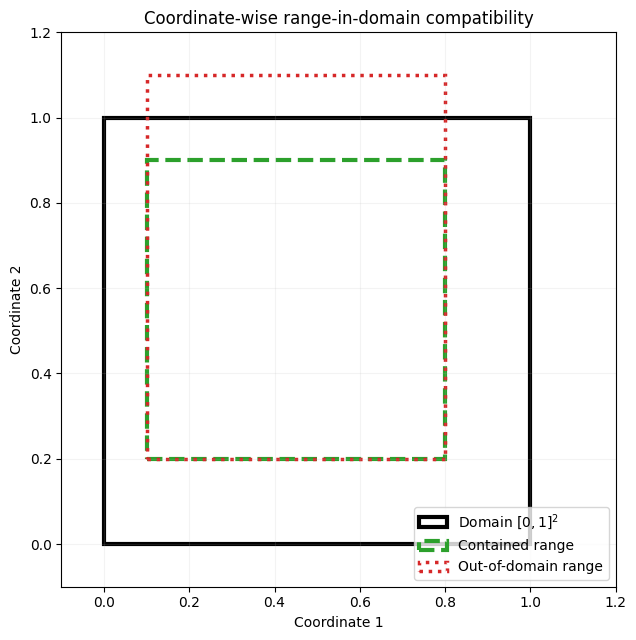

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

outer_box = Rectangle(
    (0, 0), 1, 1, fill=False, linewidth=3, color="black", label="Domain $[0,1]^2$"
)
valid_box = Rectangle(
    (0.1, 0.2),
    0.7,
    0.7,
    fill=False,
    linewidth=3,
    linestyle="--",
    color="tab:green",
    label="Contained range",
)
invalid_box = Rectangle(
    (0.1, 0.2),
    0.7,
    0.9,
    fill=False,
    linewidth=2.5,
    linestyle=":",
    color="tab:red",
    label="Out-of-domain range",
)

for box in (outer_box, valid_box, invalid_box):
    ax.add_patch(box)

ax.set(
    xlim=(-0.1, 1.2),
    ylim=(-0.1, 1.2),
    xlabel="Coordinate 1",
    ylabel="Coordinate 2",
    title="Coordinate-wise range-in-domain compatibility",
)
ax.set_aspect("equal")
ax.legend(loc="lower right")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 4. What this change solves

The current PR solves only

$$
R_{j-1}=D_j
\quad\longrightarrow\quad
R_{j-1}\subseteq D_j.
$$

This determines whether the output support of one existing `TrueMeasure` transformation can feed the domain of the next. It does **not** by itself implement arbitrary measure transport, Gaussian-to-Logistic importance sampling, forward CDF maps, or general transport/Jacobian abstractions.

## 5. QMC, Transport, and Importance Sampling

### 5.1 QMC and the role of Uniform

Sobol/DigitalNet points live in the unit cube, so direct QMC sampling begins with Uniform coordinates. Gaussian and Logistic samples are obtained separately from that reference space:

$$
U\xrightarrow{F_G^{-1}}X_G,
\qquad
U\xrightarrow{F_L^{-1}}X_L.
$$

Uniform is the reference space from which QMC points originate. We therefore need to distinguish the direction of a mathematical transport from the direction in which the QMC algorithm is actually evaluated.

### 5.2 Why the deterministic Logistic detour cancels

Let $F_G$ and $F_L$ be the Gaussian and Logistic CDFs. A deterministic Gaussian-to-Logistic transport is

$$
T_{G\to L}(x)=F_L^{-1}(F_G(x)).
$$

If that Logistic value is immediately mapped to Uniform, then

$$
F_L(T_{G\to L}(x))
=F_L(F_L^{-1}(F_G(x)))
=F_G(x).
$$

Equivalently,

$$
F_L\circ F_L^{-1}\circ F_G=F_G,
\qquad
\boxed{G\rightarrow L\rightarrow U\equiv G\rightarrow U}.
$$

If Logistic is inserted only as a deterministic transport and is immediately mapped back to Uniform, it adds no new transformation: the Logistic inverse CDF and CDF cancel.

### 5.3 Logistic as an importance-sampling proposal

Logistic becomes useful here when it is introduced as an alternative sampling measure rather than as an intermediate deterministic transport. Let $p_G$ be the Gaussian target density and $p_L$ the Logistic proposal density:

$$
I=\int_{\mathbb R}g(x)p_G(x)\,dx
=\int_{\mathbb R}g(x)\frac{p_G(x)}{p_L(x)}p_L(x)\,dx.
$$

This is a **change of measure through a likelihood ratio**, not a Gaussian-CDF-to-Logistic-inverse-CDF point transport. With $x=F_L^{-1}(u)$ and $du=p_L(x)\,dx$,

$$
\boxed{
I=\int_0^1
g(F_L^{-1}(u))
\frac{p_G(F_L^{-1}(u))}{p_L(F_L^{-1}(u))}
\,du
}.
$$

The runtime QMC path is therefore

$$
\boxed{
U_{\mathrm{Sobol}}
\xrightarrow{F_L^{-1}}
X_L
\xrightarrow{\times\,p_G(X_L)/p_L(X_L)}
\text{weighted integrand}
}.
$$

There is no Gaussian-to-Uniform transformation in this runtime path; Sobol points already supply Uniform inputs. Logistic matters because it changes the sampling measure and hence the function presented to those points.

Direct Gaussian QMC uses

$$
h_G(v)=g(F_G^{-1}(v)),
\qquad
I=\int_0^1h_G(v)\,dv,
$$

whereas Logistic importance-sampling QMC uses

$$
h_L(u)=g(F_L^{-1}(u))
\frac{p_G(F_L^{-1}(u))}{p_L(F_L^{-1}(u))},
\qquad
I=\int_0^1h_L(u)\,du.
$$

Thus

$$
\int_0^1h_G(v)\,dv=\int_0^1h_L(u)\,du,
\qquad
h_G\neq h_L\ \text{in general}.
$$

Both formulations estimate the same Gaussian integral but present different functions to the Sobol points. A proposal can therefore improve or worsen QMC behavior; Logistic is not universally better.

### 5.4 Connection: the likelihood ratio is a transport Jacobian

Define the Logistic- and Gaussian-based Uniform coordinates

$$
u=F_L(x),
\qquad
v=F_G(x).
$$

Since $x=F_L^{-1}(u)$, the map between them is

$$
T(u)=F_G(F_L^{-1}(u)).
$$

Differentiating gives

$$
\frac{dT}{du}=p_G(x)\frac{dx}{du}.
$$

Because $du/dx=p_L(x)$,

$$
\frac{dx}{du}=\frac{1}{p_L(x)},
$$

and therefore

$$
\boxed{
T'(u)=
\frac{p_G(F_L^{-1}(u))}{p_L(F_L^{-1}(u))}
}.
$$

The Gaussian/Logistic importance-sampling likelihood ratio is exactly the Jacobian of the map between their two Uniform parameterizations in one dimension. Deterministic transport and importance sampling are distinct constructions, but this Jacobian explains their mathematical connection.

The numerical check below stays away from $0$ and $1$, compares a stable finite-difference derivative with the density ratio, and then uses one deterministic DigitalNet point set for a compact same-target integral check.

Maximum interior absolute error: 8.440e-05
Mean interior absolute error: 1.535e-05
All verification values finite: True


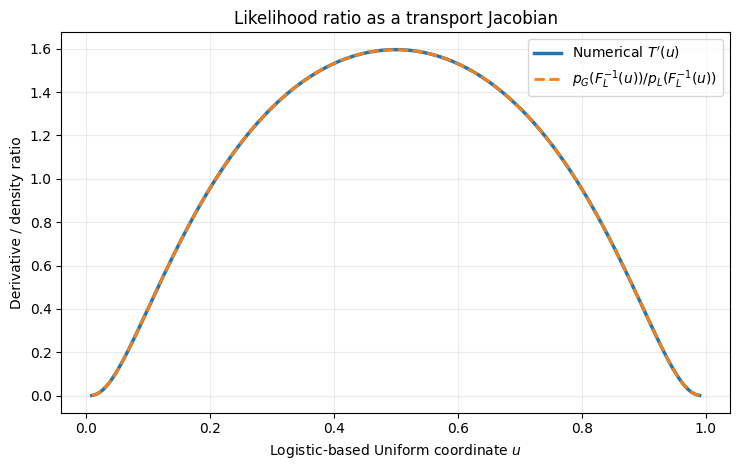

In [7]:
u = np.linspace(0.01, 0.99, 500)
x_logistic = logistic.ppf(u)
transport = norm.cdf(x_logistic)
numerical_derivative = np.gradient(transport, u, edge_order=2)
density_ratio = norm.pdf(x_logistic) / logistic.pdf(x_logistic)

interior = slice(2, -2)
absolute_error = np.abs(numerical_derivative - density_ratio)

print(
    "Maximum interior absolute error:",
    f"{absolute_error[interior].max():.3e}",
)
print(
    "Mean interior absolute error:",
    f"{absolute_error[interior].mean():.3e}",
)
print(
    "All verification values finite:",
    np.isfinite(numerical_derivative).all()
    and np.isfinite(density_ratio).all(),
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(u, numerical_derivative, linewidth=2.5, label=r"Numerical $T'(u)$")
ax.plot(
    u,
    density_ratio,
    linestyle="--",
    linewidth=2,
    label=r"$p_G(F_L^{-1}(u))/p_L(F_L^{-1}(u))$",
)
ax.set(
    xlabel="Logistic-based Uniform coordinate $u$",
    ylabel="Derivative / density ratio",
    title="Likelihood ratio as a transport Jacobian",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
qmc_u = DigitalNetB2(1, seed=7).gen_samples(2**12).reshape(-1)

gaussian_samples = norm.ppf(qmc_u)
direct_gaussian_qmc = np.mean(gaussian_samples**2)

logistic_samples = logistic.ppf(qmc_u)
logistic_weights = norm.pdf(logistic_samples) / logistic.pdf(logistic_samples)
logistic_is_qmc = np.mean(logistic_samples**2 * logistic_weights)

print("Target E[X^2]:", 1.0)
print("Direct Gaussian-QMC estimate:", f"{direct_gaussian_qmc:.9f}")
print("Logistic IS-QMC estimate:", f"{logistic_is_qmc:.9f}")
print(
    "All integral-check values finite:",
    np.isfinite(gaussian_samples).all()
    and np.isfinite(logistic_samples).all()
    and np.isfinite(logistic_weights).all(),
)

Target E[X^2]: 1.0
Direct Gaussian-QMC estimate: 0.999295953
Logistic IS-QMC estimate: 1.000000026
All integral-check values finite: True


## 6. Takeaways and next step

1. **Current PR:** chained `TrueMeasure` domain compatibility changes from exact equality to containment:

   $$
   R_{j-1}=D_j
   \quad\longrightarrow\quad
   R_{j-1}\subseteq D_j.
   $$

2. **Safety remains:** strict containment is accepted, while ranges that actually leave the next domain remain rejected.

3. **QMC direction:** Sobol points already begin in Uniform space; direct Gaussian and Logistic sampling are $U\rightarrow X_G$ and $U\rightarrow X_L$.

4. **Pure deterministic detour:** Gaussian $\rightarrow$ Logistic $\rightarrow$ Uniform collapses to Gaussian $\rightarrow$ Uniform, so inserting Logistic only as a CDF/inverse-CDF transport adds nothing by itself.

5. **Importance sampling is the meaningful alternative:** Logistic changes the sampling measure through $p_G/p_L$, and in one dimension that likelihood ratio is the Jacobian

   $$
   \frac{d}{du}F_G(F_L^{-1}(u)).
   $$

**Next question.** The current domain-inclusion PR should remain scoped as implemented. A separate follow-up can examine how QMCPy's existing importance-sampling machinery represents this Gaussian/Logistic relationship and whether any additional transport/Jacobian semantics are actually needed.